In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/indian-liver-patient-records/indian_liver_patient.csv


In [6]:
import warnings
warnings.filterwarnings('ignore')
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [7]:
df=pd.read_csv("/kaggle/input/datasets/organizations/uciml/indian-liver-patient-records/indian_liver_patient.csv")

In [8]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


# DATA PREPROCESSING

## DATA CLEANING

In [9]:
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [10]:
df.isna().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

imputer = SimpleImputer(strategy='median')
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

df.rename(columns={'Dataset': 'Target'}, inplace=True)
df['Target'] = df['Target'].astype(int)

In [12]:
df['Gender'] = df['Gender'].map({
    'Male': 1,
    'Female': 0
})

## Exploratory Data Analysis (EDA)

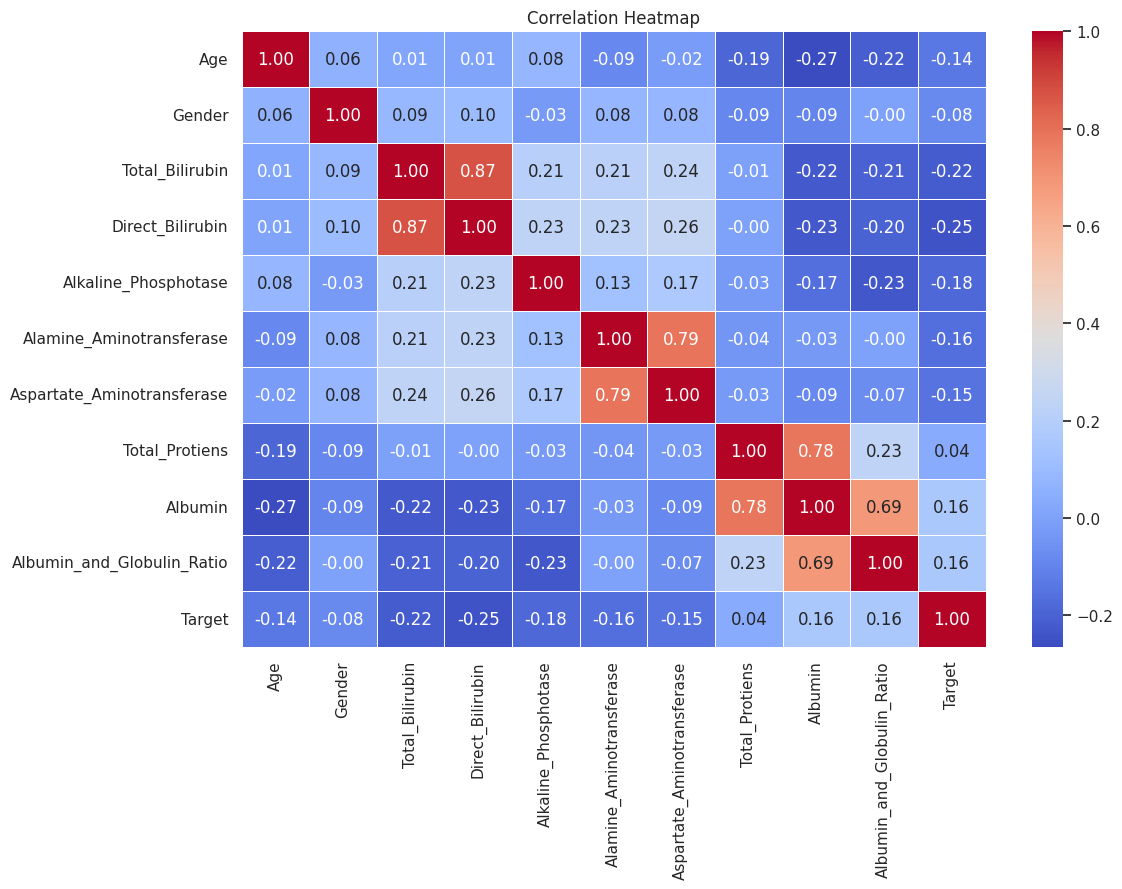

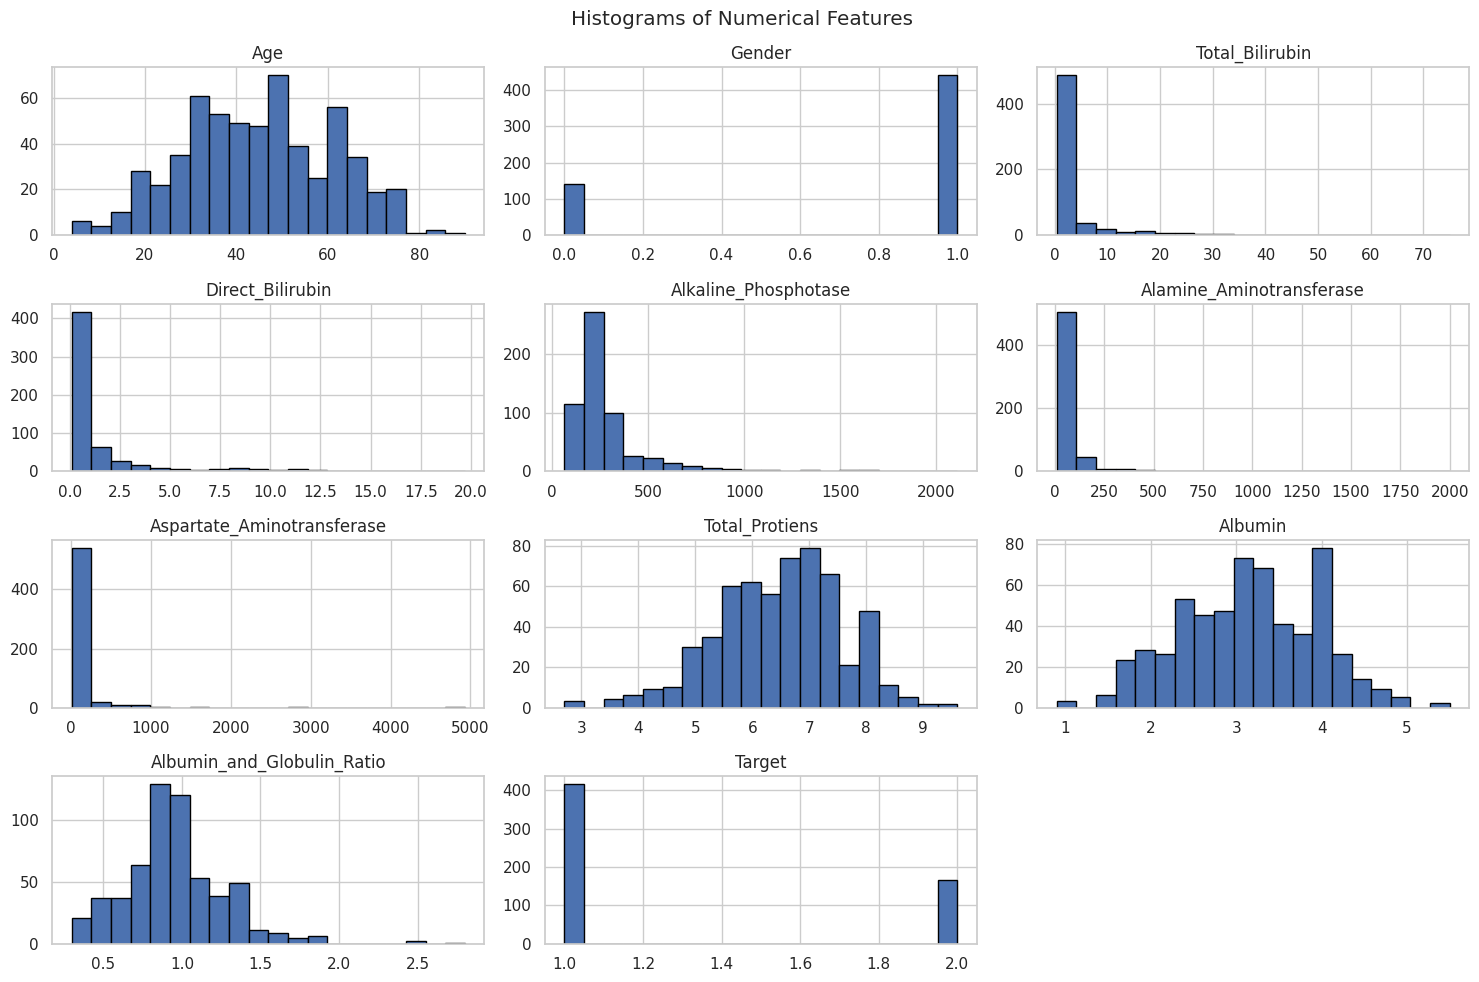

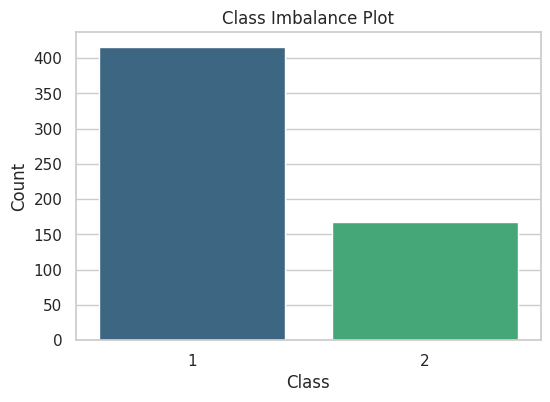

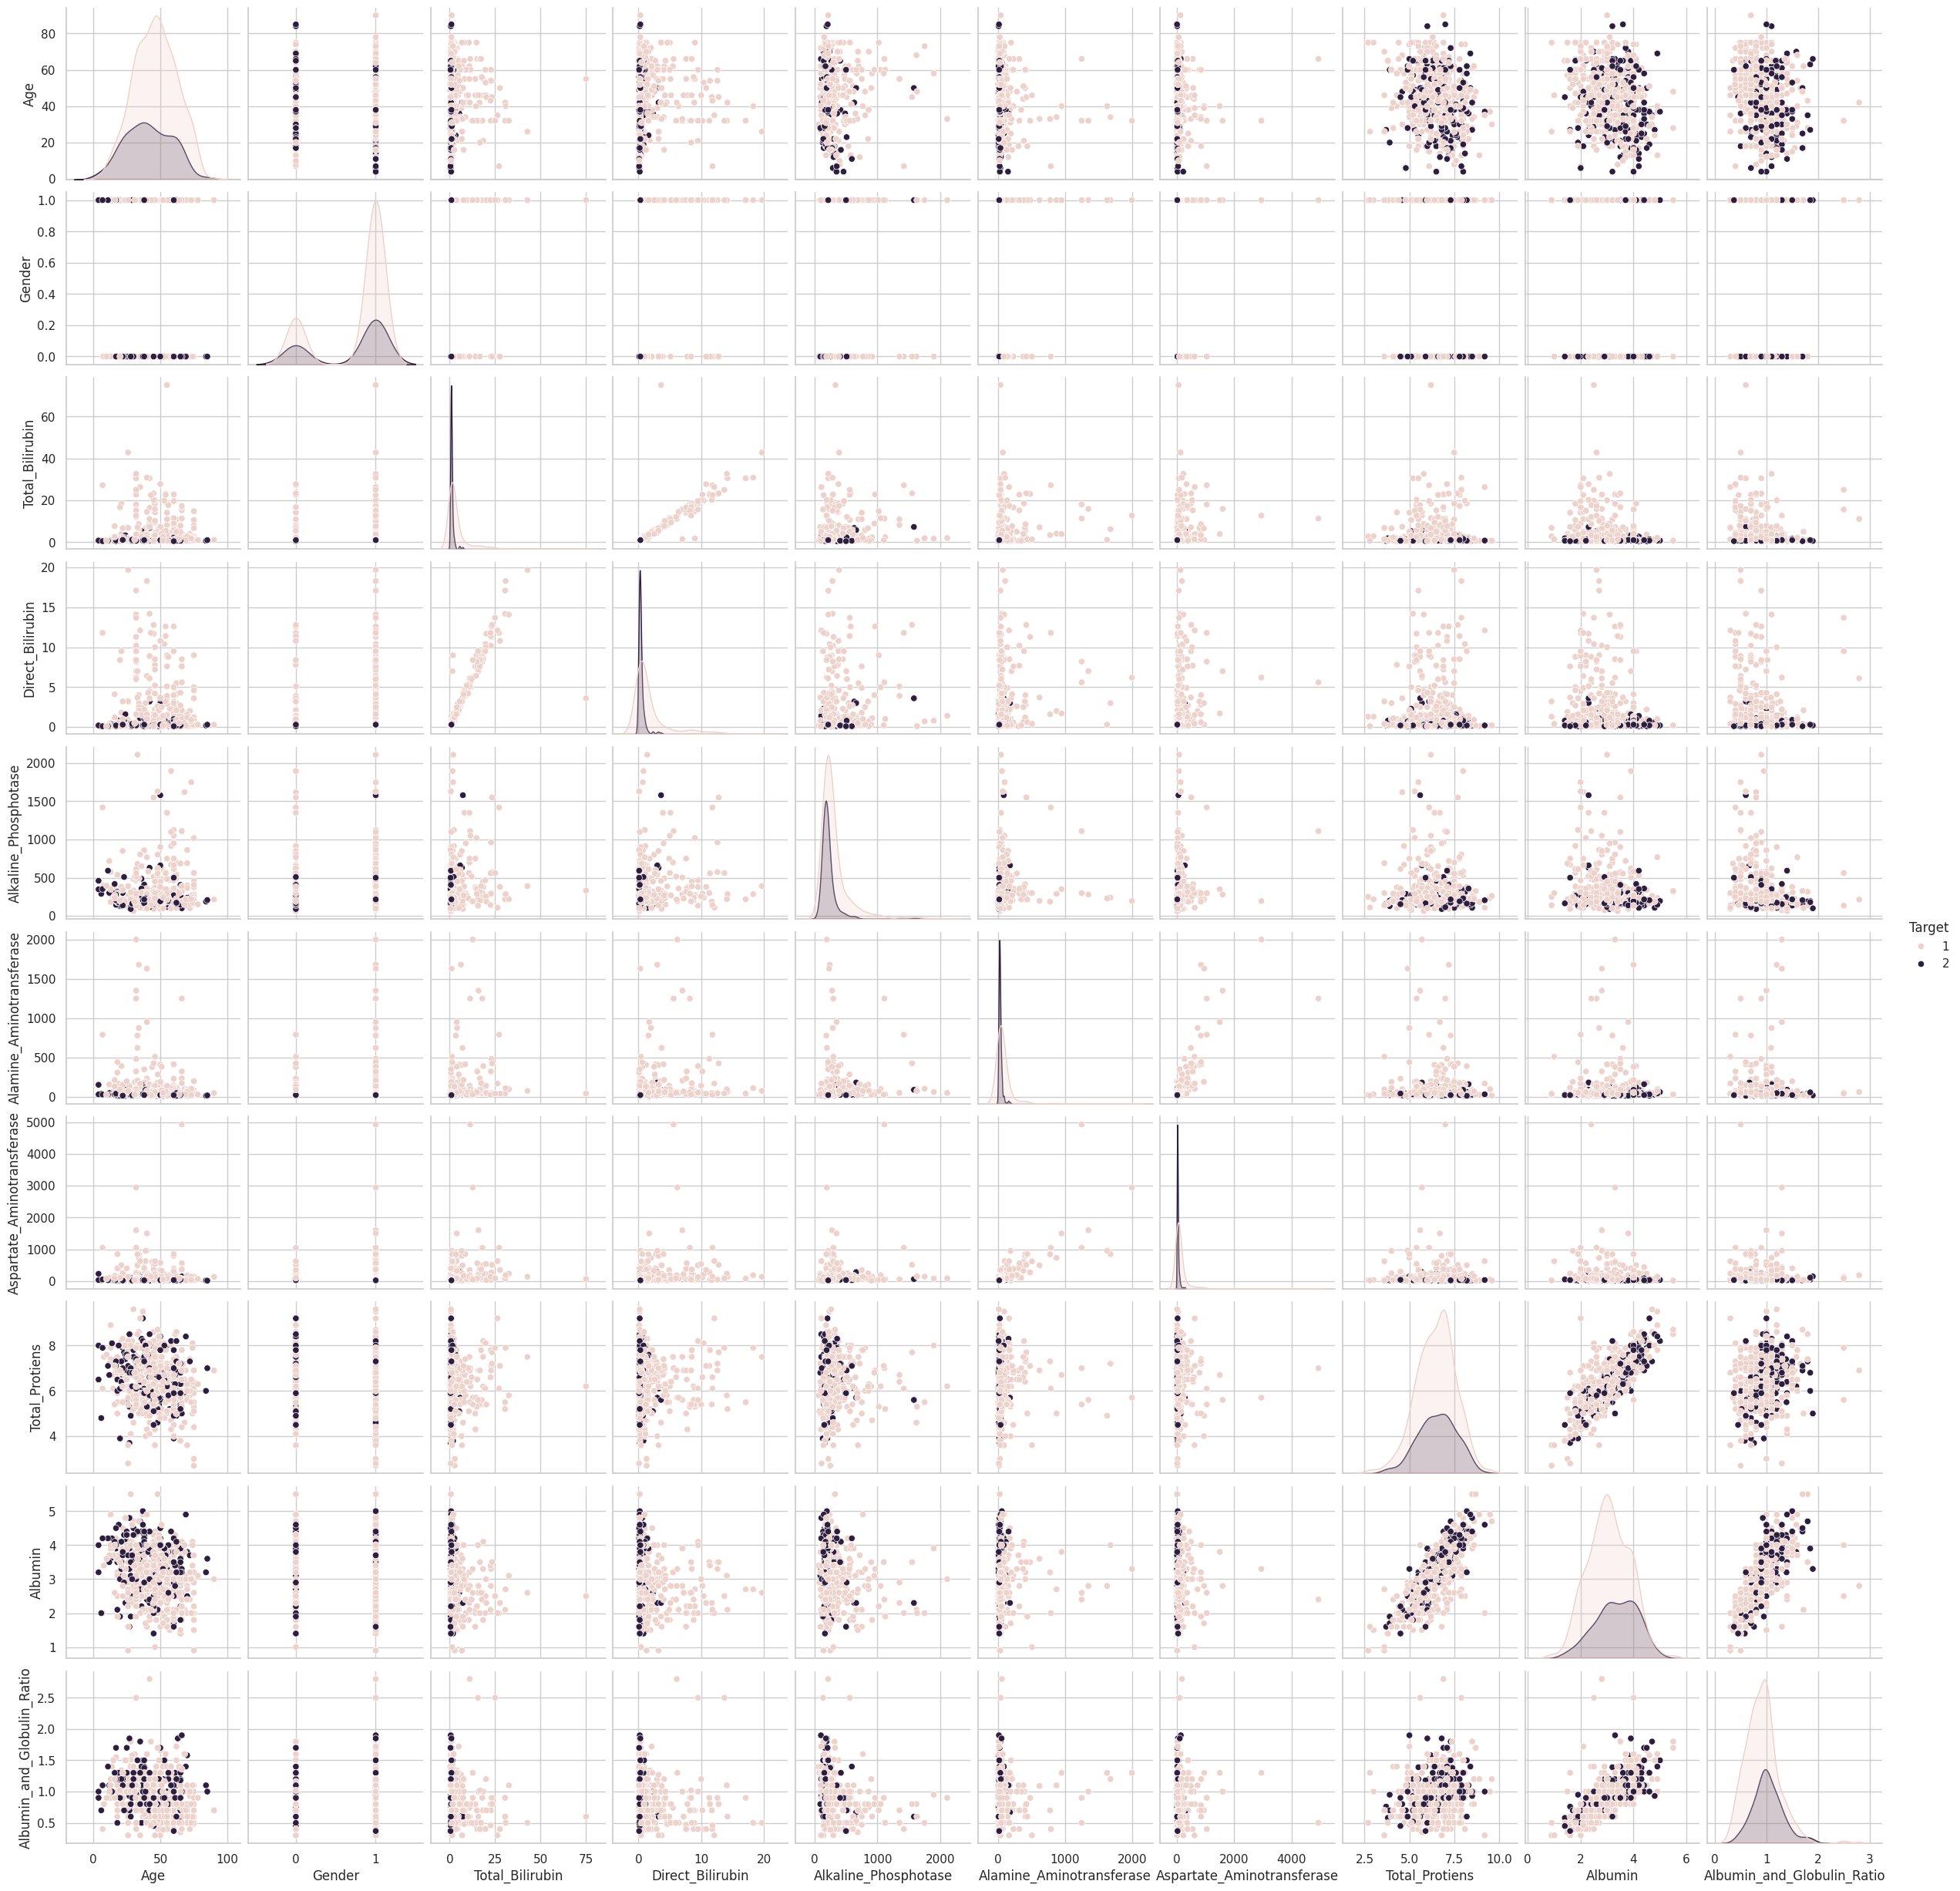

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# -----------------------------
# 1. Correlation Heatmap
# -----------------------------
plt.figure(figsize=(12, 8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()


# -----------------------------
# 2. Histograms
# -----------------------------
df.hist(
    figsize=(15, 10),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()


# -----------------------------
# 3. Class Imbalance Plot
# -----------------------------
# Replace 'target' with your actual target column name

plt.figure(figsize=(6, 4))

sns.countplot(
    x=df['Target'],
    palette='viridis'
)

plt.title("Class Imbalance Plot")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


# -----------------------------
# 4. Pairplot
# -----------------------------
# Optional: use only a few columns if dataset is large

sns.pairplot(
    df,
    hue='Target',   # remove if no target class
    diag_kind='kde'
)

plt.show()

# CAUSAL STRUCTURE LEARNING

## Discretize Features

In [14]:
df['Age_bin'] = pd.cut(
    df['Age'],
    bins=[0, 30, 60, 100],
    labels=['young', 'middle', 'old']
)
df['TB_bin'] = pd.cut(
    df['Total_Bilirubin'],
    bins=[0, 1.2, 3, 100],
    labels=['normal', 'elevated', 'severe']
)
df['DB_bin'] = pd.cut(
    df['Direct_Bilirubin'],
    bins=[0, 0.3, 1.0, 20],
    labels=['normal', 'elevated', 'severe']
)
df['DB_bin'] = pd.cut(
    df['Direct_Bilirubin'],
    bins=[0, 0.3, 1.0, 20],
    labels=['normal', 'elevated', 'severe']
)
df['ALP_bin'] = pd.qcut(
    df['Alkaline_Phosphotase'],
    q=3,
    labels=['low', 'medium', 'high']
)
df['ALT_bin'] = pd.qcut(
    df['Alamine_Aminotransferase'],
    q=3,
    labels=['low', 'medium', 'high']
)
df['AST_bin'] = pd.qcut(
    df['Aspartate_Aminotransferase'],
    q=3,
    labels=['low', 'medium', 'high']
)
df['TP_bin'] = pd.qcut(
    df['Total_Protiens'],
    q=3,
    labels=['low', 'medium', 'high']
)
df['Albumin_bin'] = pd.cut(
    df['Albumin'],
    bins=[0, 3.5, 5.0, 10],
    labels=['low', 'normal', 'high']
)
df['AGR_bin'] = pd.cut(
    df['Albumin_and_Globulin_Ratio'],
    bins=[0, 0.8, 1.2, 5],
    labels=['low', 'normal', 'high']
)

In [15]:
bayesian_df = df[
        [
        'Age_bin',
        'Gender',
        'TB_bin',
        'DB_bin',
        'ALP_bin',
        'ALT_bin',
        'AST_bin',
        'TP_bin',
        'Albumin_bin',
        'AGR_bin',
        'Target'
    ]
]

In [16]:
for col in bayesian_df.columns:
    bayesian_df[col] = bayesian_df[col].astype(str)

In [17]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 11.3 MB/s eta 0:00:00


## Learn DAG Structure

In [18]:
from pgmpy.estimators import HillClimbSearch, BIC
from pgmpy.models import BayesianNetwork

df_discrete = bayesian_df.copy()

hc = HillClimbSearch(df)

best_model = hc.estimate(scoring_method=BIC(df))
print(best_model.edges())

  0%|          | 0/1000000 [00:00<?, ?it/s]

[('Albumin', 'Albumin_bin'), ('Albumin_and_Globulin_Ratio', 'AGR_bin'), ('Age_bin', 'Age'), ('TB_bin', 'DB_bin'), ('DB_bin', 'Direct_Bilirubin'), ('DB_bin', 'Target'), ('DB_bin', 'Gender'), ('DB_bin', 'Age_bin'), ('ALT_bin', 'AST_bin'), ('ALT_bin', 'ALP_bin'), ('AST_bin', 'TB_bin'), ('TP_bin', 'Total_Protiens'), ('Albumin_bin', 'TP_bin')]


In [19]:
forbidden_edges = [

    ('Target', 'Age_bin'),
    ('Target', 'Gender'),

    ('DB_bin', 'Gender'),
    ('TB_bin', 'Gender'),

    ('DB_bin', 'Age_bin'),
    ('TB_bin', 'Age_bin'),

    ('Albumin_bin', 'Age_bin'),
    ('ALT_bin', 'Gender'),
    ('AGR_bin', 'Age_bin'),
    ('AST_bin', 'Gender'),

]
required_edges = [
    ('TB_bin', 'DB_bin'),
]

In [20]:
from pgmpy.estimators import HillClimbSearch, BIC,ExpertKnowledge

expert_knowledge = ExpertKnowledge(
    forbidden_edges=forbidden_edges,
    required_edges=required_edges
)

hc = HillClimbSearch(bayesian_df)

best_model = hc.estimate(
    scoring_method=BIC(bayesian_df),
    expert_knowledge=expert_knowledge
)
print(best_model.edges())

  0%|          | 0/1000000 [00:00<?, ?it/s]

[('Gender', 'TB_bin'), ('TB_bin', 'DB_bin'), ('TB_bin', 'AST_bin'), ('DB_bin', 'Target'), ('ALT_bin', 'ALP_bin'), ('AST_bin', 'ALT_bin'), ('TP_bin', 'Albumin_bin'), ('Albumin_bin', 'AGR_bin'), ('AGR_bin', 'TB_bin')]


## DAG

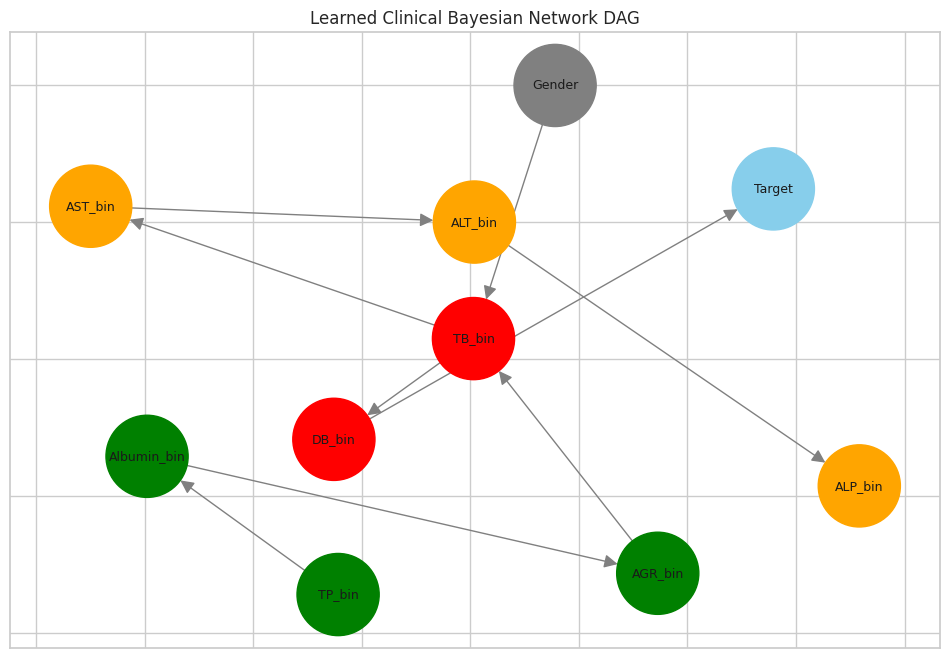

In [21]:
import os
import networkx as nx
import matplotlib.pyplot as plt

# create directory
os.makedirs("figures", exist_ok=True)

# create directed graph
G = nx.DiGraph()

# learned edges from pgmpy model
edges = list(best_model.edges())

# add edges
G.add_edges_from(edges)

node_colors = []

for node in G.nodes():

    if node in ['AST_bin', 'ALT_bin', 'ALP_bin']:
        node_colors.append('orange')

    elif node in ['TB_bin', 'DB_bin']:
        node_colors.append('red')

    elif node in ['TP_bin', 'Albumin_bin', 'AGR_bin']:
        node_colors.append('green')

    elif node == 'Target':
        node_colors.append('skyblue')

    else:
        node_colors.append('gray')
        
plt.figure(figsize=(12, 8))

# better layout for DAGs than spring (optional but recommended)
pos = nx.spring_layout(G, seed=42, k=1.5)

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    node_size=3500,
    font_size=9,
    arrowsize=20,
    node_color=node_colors,
    edge_color="gray"
)

plt.title("Learned Clinical Bayesian Network DAG")

plt.savefig(
    "figures/learned_dag.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [22]:
learned_edges = list(best_model.edges())

In [23]:
expert_edges = [

    ('Gender', 'AST_bin'),

    ('AST_bin', 'ALT_bin'),
    ('ALT_bin', 'ALP_bin'),

    ('AST_bin', 'TB_bin'),
    ('TB_bin', 'DB_bin'),

    ('DB_bin', 'Target'),

    ('Albumin_bin', 'AGR_bin'),
    ('Albumin_bin', 'TP_bin'),

]

## Comparing with Clinical DAG

In [24]:
validation = []

for edge in learned_edges:

    if edge in expert_edges:
        validity = "Yes"
    else:
        validity = "No/Partial"

    validation.append([edge, validity])

for row in validation:
    print(row)

[('Gender', 'TB_bin'), 'No/Partial']
[('TB_bin', 'DB_bin'), 'Yes']
[('TB_bin', 'AST_bin'), 'No/Partial']
[('DB_bin', 'Target'), 'Yes']
[('ALT_bin', 'ALP_bin'), 'Yes']
[('AST_bin', 'ALT_bin'), 'Yes']
[('TP_bin', 'Albumin_bin'), 'No/Partial']
[('Albumin_bin', 'AGR_bin'), 'Yes']
[('AGR_bin', 'TB_bin'), 'No/Partial']


## Structural Hamming Distance

In [25]:
expert_set = set(expert_edges)
learned_set = set(learned_edges)

extra_edges = learned_set - expert_set
missing_edges = expert_set - learned_set

shd = len(extra_edges) + len(missing_edges)

print("Extra edges:", extra_edges)
print("Missing edges:", missing_edges)
print("SHD:", shd)

Extra edges: {('TB_bin', 'AST_bin'), ('Gender', 'TB_bin'), ('TP_bin', 'Albumin_bin'), ('AGR_bin', 'TB_bin')}
Missing edges: {('Albumin_bin', 'TP_bin'), ('Gender', 'AST_bin'), ('AST_bin', 'TB_bin')}
SHD: 7


In [26]:
import pandas as pd

df_validation = pd.DataFrame(
    validation,
    columns=['Learned Edge', 'Clinically Valid']
)

df_validation.to_csv(
    "clinical_validation.csv",
    index=False
)

# BAYESIAN NETWORK TRAINING

## Learned Model

In [27]:
from pgmpy.models import DiscreteBayesianNetwork

learned_model = DiscreteBayesianNetwork(
    best_model.edges()
)

bayesian_df = bayesian_df.astype(str)

learned_model.fit(bayesian_df)

## Conditional Probability Tables

In [28]:
with open("all_cpds.txt", "w") as f:
    
    for cpd in learned_model.get_cpds():
        
        f.write(str(cpd))
        f.write("\n\n")
        f.write("="*80)
        f.write("\n\n")
        print(cpd)
        print("\n")

+-----------+----------+
| Gender(0) | 0.243568 |
+-----------+----------+
| Gender(1) | 0.756432 |
+-----------+----------+


+------------------+-----+---------------------+
| AGR_bin          | ... | AGR_bin(normal)     |
+------------------+-----+---------------------+
| Gender           | ... | Gender(1)           |
+------------------+-----+---------------------+
| TB_bin(elevated) | ... | 0.2537313432835821  |
+------------------+-----+---------------------+
| TB_bin(normal)   | ... | 0.6069651741293532  |
+------------------+-----+---------------------+
| TB_bin(severe)   | ... | 0.13930348258706468 |
+------------------+-----+---------------------+


+------------------+------------------+-----------------------+----------------+
| TB_bin           | TB_bin(elevated) | TB_bin(normal)        | TB_bin(severe) |
+------------------+------------------+-----------------------+----------------+
| DB_bin(elevated) | 0.671875         | 0.07228915662650602   | 0.0            |
+-------

In [29]:
from pgmpy.inference import VariableElimination

infer = VariableElimination(learned_model)

In [30]:
q = infer.query(
    variables=['Target'],
    evidence={
        'TB_bin': 'severe',
        'Albumin_bin': 'low'
    }
)

print(q)

q = infer.query(
    variables=['Target'],
    evidence={
        'AST_bin': 'high',
        'ALT_bin': 'high',
        'TB_bin': 'severe'
    }
)
print(q)


q = infer.query(
    variables=['Target'],
    evidence={
        'Gender': '1'
    }
)

print(q)

+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(1) |        0.9394 |
+-----------+---------------+
| Target(2) |        0.0606 |
+-----------+---------------+
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(1) |        0.9394 |
+-----------+---------------+
| Target(2) |        0.0606 |
+-----------+---------------+
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(1) |        0.7302 |
+-----------+---------------+
| Target(2) |        0.2698 |
+-----------+---------------+


In [31]:
print(learned_model.get_cpds('Target'))

+-----------+--------------------+---------------------+---------------------+
| DB_bin    | DB_bin(elevated)   | DB_bin(normal)      | DB_bin(severe)      |
+-----------+--------------------+---------------------+---------------------+
| Target(1) | 0.7090909090909091 | 0.5941558441558441  | 0.9393939393939394  |
+-----------+--------------------+---------------------+---------------------+
| Target(2) | 0.2909090909090909 | 0.40584415584415584 | 0.06060606060606061 |
+-----------+--------------------+---------------------+---------------------+


## Expert Model

In [32]:
expert_edges = [

    ('Gender', 'AST_bin'),

    ('AST_bin', 'ALT_bin'),
    ('ALT_bin', 'ALP_bin'),

    ('AST_bin', 'TB_bin'),
    ('TB_bin', 'DB_bin'),

    ('DB_bin', 'Target'),

    ('Albumin_bin', 'AGR_bin'),
    ('Albumin_bin', 'TP_bin'),

    # optional clinically meaningful addition
    ('Albumin_bin', 'Target')

]

from pgmpy.models import DiscreteBayesianNetwork

expert_model = DiscreteBayesianNetwork(
    expert_edges
)

expert_model.fit(bayesian_df)

# PROBABILISTIC INFERENCE

## Patient-Level Risk Prediction

In [33]:
from pgmpy.inference import VariableElimination

infer_learned = VariableElimination(learned_model)

infer_expert = VariableElimination(expert_model)

In [34]:
query = {
    'TB_bin': 'severe',
    'Albumin_bin': 'low'
}

q1 = infer_learned.query(
    variables=['Target'],
    evidence=query
)

print(q1)

q2 = infer_expert.query(
    variables=['Target'],
    evidence=query
)

print(q2)

+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(1) |        0.9394 |
+-----------+---------------+
| Target(2) |        0.0606 |
+-----------+---------------+
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(1) |        0.9441 |
+-----------+---------------+
| Target(2) |        0.0559 |
+-----------+---------------+


## Comparison between Learned and Expert Model

In [35]:
y_true = bayesian_df['Target']

def predict(model_infer, row, model_nodes):

    # keep only nodes present in graph
    evidence = {
        k: v
        for k, v in row.items()
        if k in model_nodes and k != 'Target'
    }

    q = model_infer.query(
        variables=['Target'],
        evidence=evidence
    )

    probs = q.values

    pred = q.state_names['Target'][probs.argmax()]

    return pred

learned_nodes = learned_model.nodes()
expert_nodes = expert_model.nodes()

y_pred_learned = []
y_pred_expert = []

for _, row in bayesian_df.iterrows():

    y_pred_learned.append(
        predict(
            infer_learned,
            row,
            learned_nodes
        )
    )

    y_pred_expert.append(
        predict(
            infer_expert,
            row,
            expert_nodes
        )
    )

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Learned DAG")

print("Accuracy",
    accuracy_score(y_true, y_pred_learned)
)

print("F1 score",
    f1_score(
        y_true,
        y_pred_learned,
        pos_label='1'
    )
)

print("Expert DAG")

print("Accuracy",
    accuracy_score(y_true, y_pred_expert)
)

print("F1 score",
    f1_score(
        y_true,
        y_pred_expert,
        pos_label='1'
    )
)

Learned DAG
Accuracy 0.7135506003430532
F1 score 0.8328328328328328
Expert DAG
Accuracy 0.7135506003430532
F1 score 0.8328328328328328


In [37]:
from sklearn.metrics import accuracy_score

y_true = bayesian_df['Target']

print(
    "Learned Accuracy:",
    accuracy_score(y_true, y_pred_learned)
)

print(
    "Expert Accuracy:",
    accuracy_score(y_true, y_pred_expert)
)

Learned Accuracy: 0.7135506003430532
Expert Accuracy: 0.7135506003430532


# UNCERTAINTY AWARENESS

## Bootstrap Sampling

In [38]:
import numpy as np
import pandas as pd

evidence = {
    'TB_bin': 'severe',
    'Albumin_bin': 'low'
}

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination

N = 500

risk_scores = []

for i in range(N):

    # bootstrap sample
    sample_df = bayesian_df.sample(
        n=len(bayesian_df),
        replace=True
    )

    # retrain model
    bootstrap_model = DiscreteBayesianNetwork(
        best_model.edges()
    )

    bootstrap_model.fit(sample_df)

    # inference
    infer = VariableElimination(
        bootstrap_model
    )

    q = infer.query(
        variables=['Target'],
        evidence=evidence
    )

    # probability of disease
    risk = q.values[0]

    risk_scores.append(risk)


mean_risk = np.mean(risk_scores)
std_risk = np.std(risk_scores)
lower = mean_risk - 1.96 * std_risk
upper = mean_risk + 1.96 * std_risk

print(
    f"Risk = {mean_risk:.2f} ± {std_risk:.2f}"
)

print(
    f"95% CI = [{lower:.2f}, {upper:.2f}]"
)

Risk = 0.94 ± 0.02
95% CI = [0.90, 0.97]


## Uncertainty Distribution

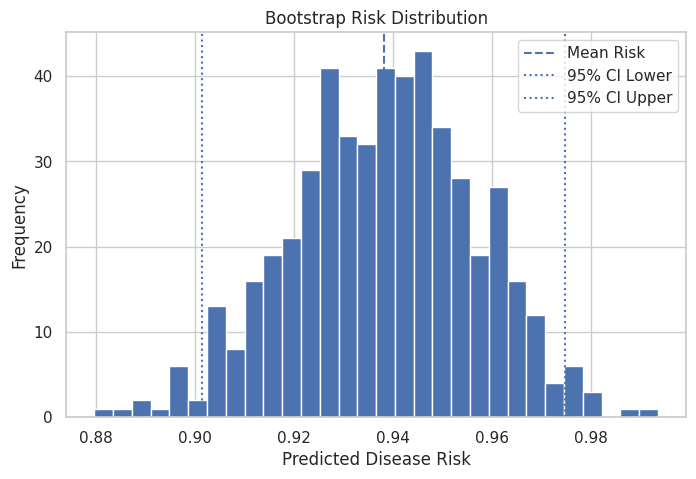

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    risk_scores,
    bins=30
)

plt.axvline(
    mean_risk,
    linestyle='--',
    label='Mean Risk'
)

plt.axvline(
    lower,
    linestyle=':',
    label='95% CI Lower'
)

plt.axvline(
    upper,
    linestyle=':',
    label='95% CI Upper'
)

plt.xlabel("Predicted Disease Risk")
plt.ylabel("Frequency")

plt.title("Bootstrap Risk Distribution")

plt.legend()

plt.savefig(
    "figures/bootstrap_uncertainty.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# COUNTERFACTUAL INTERVENTION ENGINE

In [40]:
from pgmpy.inference import VariableElimination

infer = VariableElimination(learned_model)

# risk function
def get_risk(evidence):

    q = infer.query(
        variables=['Target'],
        evidence=evidence
    )

    return q.values[0]

# original patient
patient = {
    'TB_bin': 'severe',
    'Albumin_bin': 'low'
}

# original risk
old_risk = get_risk(patient)

print("Old Risk:", old_risk)

intervention = {
    'TB_bin': 'normal',
    'Albumin_bin': 'low'
}

new_risk = get_risk(intervention)

print("New Risk:", new_risk)

Old Risk: 0.9393939393939394
New Risk: 0.6035042768476504


## Intervention Comparison Table

In [41]:
import pandas as pd

results = [

    ['Lower Bilirubin', old_risk, new_risk],

    ['Increase Albumin',
     old_risk,
     get_risk({
         'TB_bin': 'severe',
         'Albumin_bin': 'high'
     })],

]

df_interventions = pd.DataFrame(
    results,
    columns=[
        'Intervention',
        'Risk Before',
        'Risk After'
    ]
)

print(df_interventions)

df_interventions.to_csv(
    "intervention_results.csv",
    index=False
)

       Intervention  Risk Before  Risk After
0   Lower Bilirubin     0.939394    0.603504
1  Increase Albumin     0.939394    0.939394


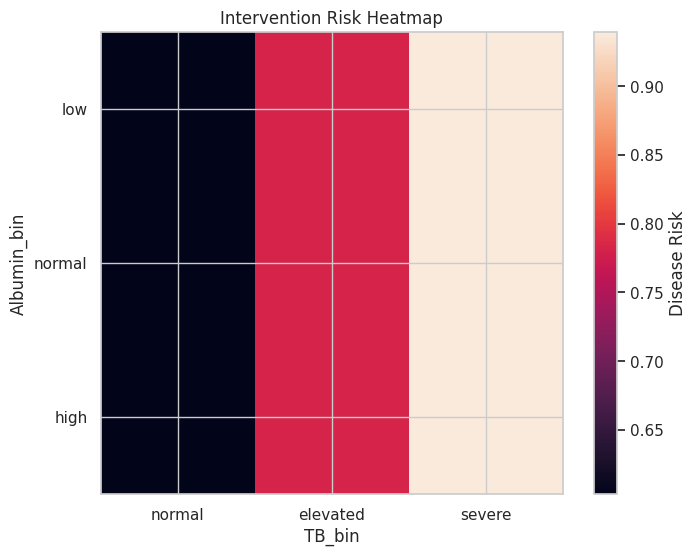

In [42]:
tb_levels = ['normal', 'elevated', 'severe']

albumin_levels = ['low', 'normal', 'high']

heatmap_data = []

for alb in albumin_levels:

    row = []

    for tb in tb_levels:

        risk = get_risk({
            'TB_bin': tb,
            'Albumin_bin': alb
        })

        row.append(risk)

    heatmap_data.append(row)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(heatmap_data)

plt.colorbar(label='Disease Risk')

plt.xticks(
    range(len(tb_levels)),
    tb_levels
)

plt.yticks(
    range(len(albumin_levels)),
    albumin_levels
)

plt.xlabel("TB_bin")
plt.ylabel("Albumin_bin")

plt.title("Intervention Risk Heatmap")

plt.savefig(
    "figures/intervention_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# OPTIMIZATION ENGINE

In [43]:
patient = {
    'TB_bin': 'severe',
    'Albumin_bin': 'low'
}
baseline_risk = get_risk(patient)

print(baseline_risk)

0.9393939393939394


In [44]:
tb_levels = [
    'normal',
    'elevated',
    'severe'
]

albumin_levels = [
    'low',
    'normal',
    'high'
]

In [45]:
target_risk = 0.70
results = []

for tb in tb_levels:

    for alb in albumin_levels:

        intervention = {
            'TB_bin': tb,
            'Albumin_bin': alb
        }

        risk = get_risk(intervention)

        # intervention distance
        distance = 0

        if tb != patient['TB_bin']:
            distance += 1

        if alb != patient['Albumin_bin']:
            distance += 1

        results.append([
            tb,
            alb,
            risk,
            distance
        ])

In [46]:
import pandas as pd

df_opt = pd.DataFrame(
    results,
    columns=[
        'TB_bin',
        'Albumin_bin',
        'Risk',
        'Distance'
    ]
)

In [47]:
safe_df = df_opt[
    df_opt['Risk'] < target_risk
]
best = safe_df.sort_values(
    by='Distance'
).iloc[0]

if len(safe_df) == 0:

    print("No feasible intervention found.")

    print(
        "Minimum achievable risk:",
        df_opt['Risk'].min()
    )

else:

    best = safe_df.sort_values(
        by='Distance'
    ).iloc[0]

    print(best)

TB_bin           normal
Albumin_bin         low
Risk           0.603504
Distance              1
Name: 0, dtype: object


In [48]:
print(df_opt.sort_values(by='Risk'))

     TB_bin Albumin_bin      Risk  Distance
0    normal         low  0.603504         1
1    normal      normal  0.603504         2
2    normal        high  0.603504         2
3  elevated         low  0.781962         1
4  elevated      normal  0.781962         2
5  elevated        high  0.781962         2
6    severe         low  0.939394         0
7    severe      normal  0.939394         1
8    severe        high  0.939394         1


## Training ML Baselines

In [49]:
!pip install imbalanced-learn catboost

In [50]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Use the cleaned dataframe already created in the notebook.
ml_df = df.copy()

X = ml_df.drop(columns=['Target'])
y = ml_df['Target'].astype(str)
positive_label = '1'

categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', one_hot, categorical_features),
    ],
    remainder='drop'
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'Extra Trees': ExtraTreesClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'SVM RBF': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes': GaussianNB(),
}

try:
    from catboost import CatBoostClassifier
    base_models['CatBoost'] = CatBoostClassifier(verbose=False, random_state=42, auto_class_weights='Balanced')
except Exception:
    print("CatBoost is not available; continuing with sklearn models.")

voting_estimators = [
    ('lr', LogisticRegression(max_iter=3000, class_weight='balanced')),
    ('rf', RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced')),
    ('et', ExtraTreesClassifier(n_estimators=250, random_state=42, class_weight='balanced')),
    ('gb', GradientBoostingClassifier(random_state=42)),
]

base_models['Soft Voting Ensemble'] = VotingClassifier(
    estimators=voting_estimators,
    voting='soft'
)

base_models['Stacking Ensemble'] = StackingClassifier(
    estimators=voting_estimators,
    final_estimator=LogisticRegression(max_iter=3000, class_weight='balanced'),
    stack_method='predict_proba',
    cv=3,
    n_jobs=-1
)

trained_models = {}
model_rows = []

for name, estimator in base_models.items():
    print(f"Training {name}...")
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    classes = list(model.classes_)

    pos_idx = classes.index(positive_label) if positive_label in classes else -1
    y_prob = model.predict_proba(X_test)[:, pos_idx]

    model_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        'Recall': recall_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        'AUC Score': roc_auc_score((y_test == positive_label).astype(int), y_prob),
    })
    trained_models[name] = model

model_results = pd.DataFrame(model_rows).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
print("\n===== ILPD ML MODEL COMPARISON =====\n")
print(model_results)
model_results.to_csv("ilpd_ml_model_comparison.csv", index=False)

best_ml_row = model_results.iloc[0]
print("\nBest ML model:", best_ml_row['Model'])

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training AdaBoost...
Training SVM RBF...
Training KNN...
Training Naive Bayes...
Training CatBoost...
Training Soft Voting Ensemble...
Training Stacking Ensemble...

===== ILPD ML MODEL COMPARISON =====

                   Model  Accuracy  Precision    Recall  F1 Score  AUC Score
0                    KNN  0.692308   0.747368  0.855422  0.797753   0.677711
1               AdaBoost  0.649573   0.728261  0.807229  0.765714   0.638554
2          Random Forest  0.623932   0.696970  0.831325  0.758242   0.649008
3      Gradient Boosting  0.632479   0.722222  0.783133  0.751445   0.631821
4            Extra Trees  0.623932   0.714286  0.783133  0.747126   0.629164
5          Decision Tree  0.623932   0.729412  0.746988  0.738095   0.535259
6   Soft Voting Ensemble  0.615385   0.715909  0.759036  0.736842   0.643161
7    Logistic Regression  0.632479   0.844

## All Models vs Bayesian Network



===== ILPD ALL MODELS vs BAYESIAN NETWORK =====

                   Model  Accuracy  Precision    Recall  F1 Score  AUC Score
0       Bayesian Network  0.713551   0.713551  1.000000  0.832833   0.684384
1                    KNN  0.692308   0.747368  0.855422  0.797753   0.677711
2               AdaBoost  0.649573   0.728261  0.807229  0.765714   0.638554
3          Random Forest  0.623932   0.696970  0.831325  0.758242   0.649008
4      Gradient Boosting  0.632479   0.722222  0.783133  0.751445   0.631821
5            Extra Trees  0.623932   0.714286  0.783133  0.747126   0.629164
6          Decision Tree  0.623932   0.729412  0.746988  0.738095   0.535259
7   Soft Voting Ensemble  0.615385   0.715909  0.759036  0.736842   0.643161
8    Logistic Regression  0.632479   0.844828  0.590361  0.695035   0.645641
9               CatBoost  0.606838   0.793651  0.602410  0.684932   0.670801
10               SVM RBF  0.623932   0.882353  0.542169  0.671642   0.716867
11     Stacking Ensemble  

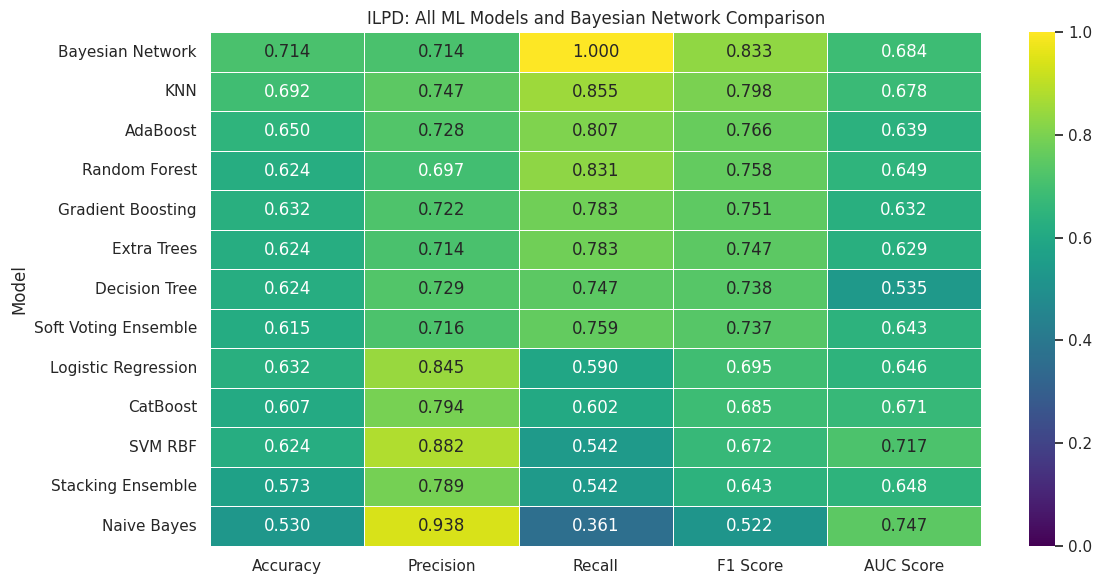

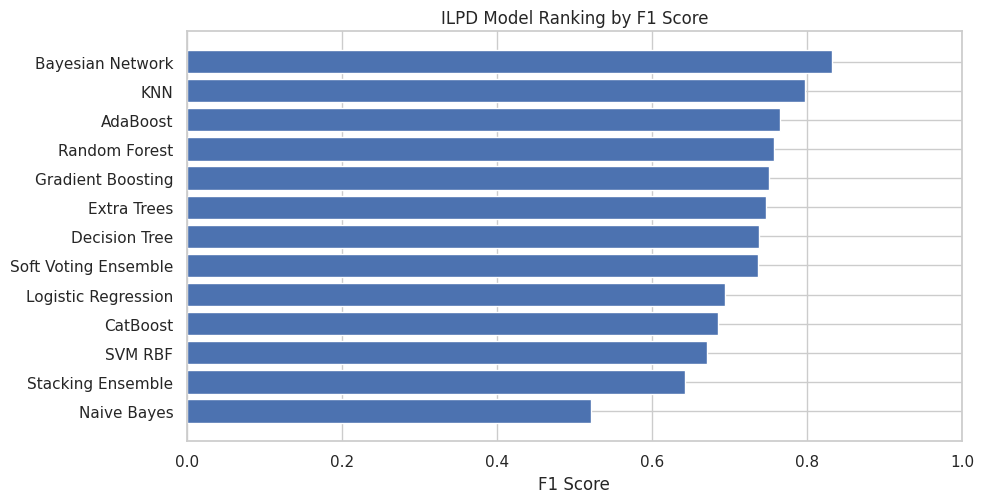

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

bn_y_true = bayesian_df['Target'].astype(str)
bn_y_pred = pd.Series(y_pred_learned).astype(str)

bn_probs = []
for _, row in bayesian_df.iterrows():
    evidence = {
        k: v
        for k, v in row.items()
        if k in learned_nodes and k != 'Target'
    }
    q = infer_learned.query(variables=['Target'], evidence=evidence)
    states = list(q.state_names['Target'])
    if positive_label in states:
        bn_probs.append(float(q.values[states.index(positive_label)]))
    else:
        bn_probs.append(float(np.max(q.values)))

bn_row = {
    'Model': 'Bayesian Network',
    'Accuracy': accuracy_score(bn_y_true, bn_y_pred),
    'Precision': precision_score(bn_y_true, bn_y_pred, pos_label=positive_label, zero_division=0),
    'Recall': recall_score(bn_y_true, bn_y_pred, pos_label=positive_label, zero_division=0),
    'F1 Score': f1_score(bn_y_true, bn_y_pred, pos_label=positive_label, zero_division=0),
    'AUC Score': roc_auc_score((bn_y_true == positive_label).astype(int), bn_probs),
}

all_results = pd.concat(
    [model_results, pd.DataFrame([bn_row])],
    ignore_index=True
).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

print("\n===== ILPD ALL MODELS vs BAYESIAN NETWORK =====\n")
print(all_results)
all_results.to_csv("ilpd_all_models_vs_bayesian.csv", index=False)

import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC Score']
plot_df = all_results.set_index('Model')[metrics]

plt.figure(figsize=(12, max(6, 0.45 * len(plot_df))))
sns.heatmap(
    plot_df,
    annot=True,
    cmap='viridis',
    fmt='.3f',
    linewidths=0.5,
    vmin=0,
    vmax=1
)
plt.title("ILPD: All ML Models and Bayesian Network Comparison")
plt.tight_layout()
plt.savefig("figures/ilpd_all_models_vs_bayesian_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

ranked = all_results.sort_values(by='F1 Score', ascending=True)
plt.figure(figsize=(10, max(5, 0.4 * len(ranked))))
plt.barh(ranked['Model'], ranked['F1 Score'])
plt.xlabel("F1 Score")
plt.title("ILPD Model Ranking by F1 Score")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("figures/ilpd_model_f1_ranking.png", dpi=300, bbox_inches='tight')
plt.show()

# LLM EXPLANATION

In [53]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GROQ_API_KEY")

In [54]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.3 MB/s eta 0:00:00


In [55]:
# ============================================================
# PHASE 9 — LLM EXPLANATION MODULE
# USING GROQ API
# ============================================================
from groq import Groq

# ============================================================
# GROQ API KEY
# ============================================================

GROQ_API_KEY = secret_value_0

client = Groq(
    api_key=GROQ_API_KEY
)

# ============================================================
# INPUTS FROM YOUR PIPELINE
# ============================================================

# learned DAG edges
dag_edges = list(learned_model.edges())

# predicted risk
risk = 0.94

# confidence interval
confidence_interval = [0.90, 0.97]

# intervention results
interventions = {

    "Lower Bilirubin": {
        "before": 0.94,
        "after": 0.60
    },

    "Increase Albumin": {
        "before": 0.94,
        "after": 0.94
    },

    "Combined Intervention": {
        "before": 0.94,
        "after": 0.60
    }
}

# ============================================================
# CREATE STRUCTURED PROMPT
# ============================================================

prompt = f"""
You are an AI clinical reasoning assistant.

A Bayesian causal network was trained for liver disease analysis.

Learned causal DAG edges:
{dag_edges}

Predicted liver disease risk:
{risk}

95% confidence interval:
{confidence_interval}

Intervention analysis:
{interventions}

Generate:
1. Primary risk drivers
2. Interpretation of confidence interval
3. Most effective intervention
4. Short clinical explanation

Keep explanation concise and medically interpretable.
"""

# ============================================================
# CALL GROQ LLM
# ============================================================

response = client.chat.completions.create(

    model="llama-3.3-70b-versatile",

    messages=[
        {
            "role": "system",
            "content": "You are a medical AI assistant."
        },

        {
            "role": "user",
            "content": prompt
        }
    ],

    temperature=0.3
)

# ============================================================
# OUTPUT
# ============================================================

explanation = response.choices[0].message.content

print("\n================ LLM EXPLANATION ================\n")

print(explanation)

# ============================================================
# SAVE EXPLANATION
# ============================================================

with open("llm_clinical_explanation.txt", "w") as f:

    f.write(explanation)


================ LLM EXPLANATION ================

**1. Primary risk drivers:** 
Based on the causal DAG edges, primary risk drivers for liver disease are 'DB_bin' (Direct Bilirubin) and 'AST_bin' (Aspartate Aminotransferase), as they directly influence 'Target' (liver disease risk) or are part of a chain leading to it.

**2. Interpretation of confidence interval:** 
The 95% confidence interval [0.9, 0.97] indicates that we are 95% confident the true liver disease risk lies between 0.9 and 0.97, suggesting a high risk of liver disease.

**3. Most effective intervention:** 
The most effective intervention is 'Lower Bilirubin' or 'Combined Intervention', as both reduce the predicted liver disease risk from 0.94 to 0.6.

**4. Short clinical explanation:** 
The patient has a high risk of liver disease (0.94). Lowering bilirubin levels is the most effective way to reduce this risk. This is likely because elevated bilirubin is a marker of liver dysfunction, and reducing it can alleviate liv

# EVALUATION

In [56]:
best_overall_row = all_results.sort_values(by='F1 Score', ascending=False).iloc[0]
bayesian_row = all_results[all_results['Model'] == 'Bayesian Network'].iloc[0]

final_results = pd.DataFrame({
    'Metric': [
        'Best Overall Model',
        'Best Overall Accuracy',
        'Best Overall F1 Score',
        'Best Overall AUC Score',
        'Best ML Model',
        'Bayesian Network Accuracy',
        'Bayesian Network F1 Score',
        'Bayesian Network AUC Score',
        'SHD',
        'Confidence Interval Width',
        'Risk Reduction (%)'
    ],
    'Value': [
        best_overall_row['Model'],
        round(best_overall_row['Accuracy'], 4),
        round(best_overall_row['F1 Score'], 4),
        round(best_overall_row['AUC Score'], 4),
        best_ml_row['Model'],
        round(bayesian_row['Accuracy'], 4),
        round(bayesian_row['F1 Score'], 4),
        round(bayesian_row['AUC Score'], 4),
        shd,
        round(upper - lower, 4),
        round(((old_risk - new_risk) / old_risk) * 100, 2) if old_risk else 0
    ]
})

print("\n===== ILPD FINAL SUMMARY TABLE =====\n")
print(final_results)

print("\n===== ILPD FULL MODEL COMPARISON TABLE =====\n")
print(all_results)

final_results.to_csv("ilpd_final_metrics_table.csv", index=False)
all_results.to_csv("ilpd_final_all_models_comparison.csv", index=False)


===== ILPD FINAL SUMMARY TABLE =====

                        Metric             Value
0           Best Overall Model  Bayesian Network
1        Best Overall Accuracy            0.7136
2        Best Overall F1 Score            0.8328
3       Best Overall AUC Score            0.6844
4                Best ML Model               KNN
5    Bayesian Network Accuracy            0.7136
6    Bayesian Network F1 Score            0.8328
7   Bayesian Network AUC Score            0.6844
8                          SHD                 7
9    Confidence Interval Width            0.0733
10          Risk Reduction (%)             35.76

===== ILPD FULL MODEL COMPARISON TABLE =====

                   Model  Accuracy  Precision    Recall  F1 Score  AUC Score
0       Bayesian Network  0.713551   0.713551  1.000000  0.832833   0.684384
1                    KNN  0.692308   0.747368  0.855422  0.797753   0.677711
2               AdaBoost  0.649573   0.728261  0.807229  0.765714   0.638554
3          Random 